# Spike/Ripple Probability Distribution

This version keeps the original analysis structure but uses one consistent index system:

- `embedding`: all **31,847** candidates, indexed by the original global index.
- EC130 and EC183 are excluded only when building the selected subset.
- `selected_global_idx`: the **30,162** retained global indices.
- Prediction probabilities, labels, patient names, UMAP coordinates, KMeans labels, and heatmap values are all aligned through the same global indices.

The notebook intentionally keeps the original UMAP and clustering settings unless noted otherwise.

In [1]:
import os
import glob
import re
import collections

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.io import loadmat
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min
from sklearn.neighbors import KNeighborsClassifier
from scipy.spatial import cKDTree

import umap.umap_ as umap

In [2]:
# Patient/channel configuration
pt_ch_mapping = {
    "EC130_200": [1, 13],
    "EC133_200": [282, 291, 292, 293],
    "EC135_200": [303],
    "EC137_200": [257, 258, 259, 269],
    "EC143_200": [339],
    "EC157_200": [321, 332, 333, 334],
    "EC162_200": [85, 86],
    "EC175_200": [301, 302],
    "EC183_200": [290],
    "EC186_200": [299, 300, 301],
    "EC187_200": [309, 310],
    "EC191_200": [2, 3, 4],
    "EC196_200": [300, 301, 303],
    "EC219_200": [399, 400, 402, 403],
    "EC220_200": [53, 54, 76, 77],
    "EC221_200": [376, 377],
    "EC222_200": [267, 268, 269, 270],
}

# Original expected counts
patient_num = {
    "EC130_200": 1465,
    "EC133_200": 1220,
    "EC135_200": 344,
    "EC137_200": 7222,
    "EC143_200": 881,
    "EC157_200": 4747,
    "EC162_200": 2398,
    "EC175_200": 518,
    "EC183_200": 220,
    "EC186_200": 1710,
    "EC187_200": 1315,
    "EC191_200": 642,
    "EC196_200": 594,
    "EC219_200": 2015,
    "EC220_200": 2572,
    "EC221_200": 859,
    "EC222_200": 3125,
}

EXCLUDED_PATIENTS = {"EC130_200", "EC183_200"}
EXPECTED_GLOBAL_N = 31847
EXPECTED_SELECTED_N = 30162

pathname = "/scratch/dazhang/MATLAB/"

print("Expected total:", sum(patient_num.values()))
print("Expected selected:", sum(
    n for patient, n in patient_num.items()
    if patient not in EXCLUDED_PATIENTS
))

Expected total: 31847
Expected selected: 30162


In [3]:
# Load all ripple feature vectors in the original 31,847-row order
all_specs_label = np.array([], dtype=object)
all_specs = np.empty((0, 60))
file_list = []

for patient, channel_list in pt_ch_mapping.items():
    patient_path = os.path.join(pathname, patient)
    ls_specs = np.empty((0, 60))

    for cur_channel in channel_list:
        cur_channel = str(cur_channel)

        for filename in sorted(glob.glob(os.path.join(patient_path, "*.mat"))):
            if "ls_ripple" not in filename or "binsize_1_" in filename:
                continue

            if f"Channel_{cur_channel}_" in filename and "-empty" not in filename:
                specs = loadmat(filename)["ls_ripple"]
                file_list.append(filename)
                ls_specs = np.concatenate([ls_specs, specs], axis=0)

    all_specs = np.concatenate([all_specs, ls_specs], axis=0)
    all_specs_label = np.concatenate([
        all_specs_label,
        np.array([patient] * len(ls_specs), dtype=object)
    ])

    expected_n = patient_num[patient]
    print(f"{patient}: loaded={len(ls_specs)}, expected={expected_n}")

print("\nall_specs shape:", all_specs.shape)
print("all_specs_label shape:", all_specs_label.shape)

assert len(all_specs) == len(all_specs_label)
assert len(all_specs) == EXPECTED_GLOBAL_N, (
    f"Expected {EXPECTED_GLOBAL_N} global candidates, got {len(all_specs)}"
)

EC130_200: loaded=1465, expected=1465
EC133_200: loaded=1220, expected=1220
EC135_200: loaded=344, expected=344
EC137_200: loaded=7222, expected=7222
EC143_200: loaded=881, expected=881
EC157_200: loaded=4747, expected=4747
EC162_200: loaded=2398, expected=2398
EC175_200: loaded=518, expected=518
EC183_200: loaded=220, expected=220
EC186_200: loaded=1710, expected=1710
EC187_200: loaded=1315, expected=1315
EC191_200: loaded=642, expected=642
EC196_200: loaded=594, expected=594
EC219_200: loaded=2015, expected=2015
EC220_200: loaded=2572, expected=2572
EC221_200: loaded=859, expected=859
EC222_200: loaded=3125, expected=3125

all_specs shape: (31847, 60)
all_specs_label shape: (31847,)


In [4]:
# Load corresponding spike labels in the same global order
all_spikes_label = np.empty((0, 1))

for each_file in file_list:
    patient_name = each_file.split("/")[-2]
    actual_file = each_file.split("/")[-1]
    actual_file_list = actual_file.split("_")

    spike_file_name = (
        pathname
        + patient_name
        + "/"
        + actual_file_list[0]
        + "_spikes_"
        + "_".join(actual_file_list[2:6])
        + "_1_"
        + "_".join(actual_file_list[7:])
    )

    spikes = loadmat(spike_file_name)["ls_spikes"]
    all_spikes_label = np.concatenate([all_spikes_label, spikes], axis=0)

print("all_spikes_label shape:", all_spikes_label.shape)

assert len(all_spikes_label) == EXPECTED_GLOBAL_N

all_spikes_label shape: (31847, 1)


In [5]:
# UMAP on all 31,847 candidates
all_vectors = np.asarray(all_specs)

embedding = umap.UMAP(
    n_components=2,
    min_dist=0.2,
    metric="euclidean",
    n_neighbors=15,
    random_state=42,
    n_epochs=100,
    verbose=True
).fit_transform(all_vectors)

print("embedding shape:", embedding.shape)
assert embedding.shape == (EXPECTED_GLOBAL_N, 2)

UMAP(min_dist=0.2, n_epochs=100, n_jobs=1, random_state=42, verbose=True)
Sun Sep 20 03:17:35 2026 Construct fuzzy simplicial set
Sun Sep 20 03:17:35 2026 Finding Nearest Neighbors
Sun Sep 20 03:17:35 2026 Building RP forest with 14 trees


/home/dazhang/anaconda3/envs/klab/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Sun Sep 20 03:17:40 2026 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	 3  /  15
	 4  /  15
	Stopping threshold met -- exiting after 4 iterations
Sun Sep 20 03:17:57 2026 Finished Nearest Neighbor Search
Sun Sep 20 03:18:00 2026 Construct embedding


Epochs completed:   0%|            0/100 [00:00]

	completed  0  /  100 epochs
	completed  10  /  100 epochs
	completed  20  /  100 epochs
	completed  30  /  100 epochs
	completed  40  /  100 epochs
	completed  50  /  100 epochs
	completed  60  /  100 epochs
	completed  70  /  100 epochs
	completed  80  /  100 epochs
	completed  90  /  100 epochs
Sun Sep 20 03:18:07 2026 Finished embedding
embedding shape: (31847, 2)


In [6]:
# Parsing helpers

def parse_numeric_line(line):
    """
    Parse values from lines such as:
      [0.1, 0.2]
      [np.float32(0.1), np.float32(0.2)]
      [np.int64(1), np.int64(2)]
    """
    line = line.strip()
    line = re.sub(r"np\\.(?:float|int)(?:32|64)\\(([^()]*)\\)", r"\\1", line)
    line = line.strip("[]() \\n\\t")

    if not line:
        return []

    pieces = re.split(r"[,\\s]+", line)
    return [float(x) for x in pieces if x.strip()]


def read_numeric_file(filename):
    values = []
    with open(filename, "r") as f:
        for line in f:
            values.extend(parse_numeric_line(line))
    return values


def read_index_file(filename):
    values = read_numeric_file(filename)
    return np.asarray([int(float(x)) for x in values], dtype=int)


## Build the 30,162-sample subset using 31,847-space global indices

The key rule is:

`patient-local index -> 31,847-space global index -> aligned probability / label / patient / embedding`

No downstream analysis uses `start_id + idx` or a separate 30,162-local index system as the source of truth.

In [7]:
global_idx_list = []
prob_list_all_patient = []
label_list_all_patient = []
patient_list_all_patient = []

for patient in pt_ch_mapping:
    if patient in EXCLUDED_PATIENTS:
        continue

    label_file = f"true_label_file_exclude_{patient}_200.txt"
    pred_file = f"true_pred_file_exclude_{patient}_200.txt"
    spike_idx_file = f"{patient[:-4]}_spikes_idx_correct_200.txt"
    ripple_idx_file = f"{patient[:-4]}_ripples_idx_correct_200.txt"

    labels = np.asarray(read_numeric_file(label_file), dtype=float)
    probs = np.asarray(read_numeric_file(pred_file), dtype=float)
    spike_local_idx = read_index_file(spike_idx_file)
    ripple_local_idx = read_index_file(ripple_idx_file)

    # Preserve the original order used by the old notebook:
    # spike indices first, then ripple indices.
    local_idx = np.concatenate([spike_local_idx, ripple_local_idx])

    print(
        f"{patient}: probs={len(probs)}, labels={len(labels)}, "
        f"spikes={len(spike_local_idx)}, ripples={len(ripple_local_idx)}, "
        f"indices={len(local_idx)}"
    )

    assert len(probs) == len(labels), (
        f"Probability/label mismatch for {patient}: "
        f"{len(probs)} vs {len(labels)}"
    )
    assert len(probs) == len(local_idx), (
        f"Probability/index mismatch for {patient}: "
        f"{len(probs)} vs {len(local_idx)}"
    )

    # All global rows belonging to this patient, in the exact order of all_specs.
    patient_global_indices = np.where(all_specs_label == patient)[0]

    assert len(patient_global_indices) == patient_num[patient]
    assert np.min(local_idx) >= 0
    assert np.max(local_idx) < len(patient_global_indices)

    # Convert patient-local indices to true 31,847-space global indices.
    patient_selected_global_idx = patient_global_indices[local_idx]

    global_idx_list.extend(patient_selected_global_idx.tolist())
    prob_list_all_patient.extend(probs.tolist())
    label_list_all_patient.extend(labels.tolist())
    patient_list_all_patient.extend([patient] * len(probs))

global_idx_list = np.asarray(global_idx_list, dtype=int)
prob_list_all_patient = np.asarray(prob_list_all_patient, dtype=float)
label_list_all_patient = np.asarray(label_list_all_patient, dtype=float)
patient_list_all_patient = np.asarray(patient_list_all_patient, dtype=object)

print("\nLengths:")
print("global_idx_list:", len(global_idx_list))
print("probabilities:", len(prob_list_all_patient))
print("labels:", len(label_list_all_patient))
print("patients:", len(patient_list_all_patient))

assert len(global_idx_list) == EXPECTED_SELECTED_N
assert len(prob_list_all_patient) == EXPECTED_SELECTED_N
assert len(label_list_all_patient) == EXPECTED_SELECTED_N
assert len(patient_list_all_patient) == EXPECTED_SELECTED_N

# Every retained sample should have one unique global index.
assert len(np.unique(global_idx_list)) == EXPECTED_SELECTED_N

EC133_200: probs=1220, labels=1220, spikes=160, ripples=1060, indices=1220
EC135_200: probs=344, labels=344, spikes=9, ripples=335, indices=344
EC137_200: probs=7222, labels=7222, spikes=26, ripples=7196, indices=7222
EC143_200: probs=881, labels=881, spikes=11, ripples=870, indices=881
EC157_200: probs=4747, labels=4747, spikes=183, ripples=4564, indices=4747
EC162_200: probs=2398, labels=2398, spikes=42, ripples=2356, indices=2398
EC175_200: probs=518, labels=518, spikes=26, ripples=492, indices=518
EC186_200: probs=1710, labels=1710, spikes=807, ripples=903, indices=1710
EC187_200: probs=1315, labels=1315, spikes=2, ripples=1313, indices=1315
EC191_200: probs=642, labels=642, spikes=62, ripples=580, indices=642
EC196_200: probs=594, labels=594, spikes=51, ripples=543, indices=594
EC219_200: probs=2015, labels=2015, spikes=37, ripples=1978, indices=2015
EC220_200: probs=2572, labels=2572, spikes=108, ripples=2464, indices=2572
EC221_200: probs=859, labels=859, spikes=35, ripples=824,

In [8]:
# Independently build the retained global subset by patient label.
selected_global_idx = np.where(
    ~np.isin(all_specs_label, list(EXCLUDED_PATIENTS))
)[0]

print("selected_global_idx:", len(selected_global_idx))
assert len(selected_global_idx) == EXPECTED_SELECTED_N

# This is the strongest alignment check:
# both methods must identify exactly the same 30,162 global samples.
same_global_set = np.array_equal(
    np.sort(global_idx_list),
    np.sort(selected_global_idx)
)

print("global_idx_list matches selected_global_idx:", same_global_set)
assert same_global_set

# Store probability/label in the original 31,847 global space.
prob_by_global = np.full(EXPECTED_GLOBAL_N, np.nan, dtype=float)
label_by_global = np.full(EXPECTED_GLOBAL_N, np.nan, dtype=float)

prob_by_global[global_idx_list] = prob_list_all_patient
label_by_global[global_idx_list] = label_list_all_patient

# Downstream arrays are all generated from the same selected_global_idx order.
each_pt_embedding = embedding[selected_global_idx]
selected_probs = prob_by_global[selected_global_idx]
selected_labels = label_by_global[selected_global_idx]
selected_patients = all_specs_label[selected_global_idx]

print("each_pt_embedding:", each_pt_embedding.shape)
print("selected_probs:", selected_probs.shape)
print("selected_labels:", selected_labels.shape)
print("selected_patients:", selected_patients.shape)

assert each_pt_embedding.shape == (EXPECTED_SELECTED_N, 2)
assert not np.isnan(selected_probs).any()
assert not np.isnan(selected_labels).any()

selected_global_idx: 30162
global_idx_list matches selected_global_idx: True
each_pt_embedding: (30162, 2)
selected_probs: (30162,)
selected_labels: (30162,)
selected_patients: (30162,)


min/max probability: 0.16 0.77
mapped probability range: 0.1574918628 0.7656844258
plot arrays: 30162 30162 30162


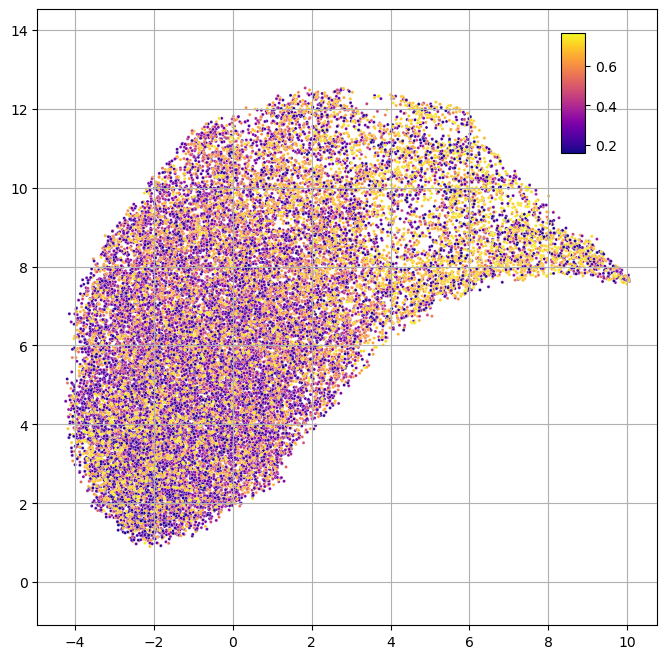

In [9]:
# Probability color mapping and UMAP probability scatter
min_prob = round(float(np.min(selected_probs)), 2)
max_prob = round(float(np.max(selected_probs)), 2)

print("min/max probability:", min_prob, max_prob)

prob_space = np.linspace(min_prob, max_prob, num=100)
plasma = plt.colormaps["plasma"]

prob_values = []
all_pt_color = []

for prob in selected_probs:
    nearest_prob = min(prob_space, key=lambda x: abs(x - prob))

    if max_prob == min_prob:
        mapped_value = 0.0
    else:
        mapped_value = (nearest_prob - min_prob) / (max_prob - min_prob)

    prob_values.append(prob)
    all_pt_color.append(plasma(mapped_value)[:-1])

prob_values = np.asarray(prob_values, dtype=float)
all_pt_color = np.asarray(all_pt_color)

print("mapped probability range:", np.min(prob_values), np.max(prob_values))
print("plot arrays:", len(each_pt_embedding), len(prob_values), len(all_pt_color))

fig, ax = plt.subplots(figsize=(8, 8))

sns.scatterplot(
    x=each_pt_embedding[:, 0],
    y=each_pt_embedding[:, 1],
    c=all_pt_color,
    s=5.0,
    ax=ax
)

ax.grid(True)
ax.axis("equal")

norm = plt.Normalize(np.min(prob_values), np.max(prob_values))
sm = plt.cm.ScalarMappable(cmap=plasma, norm=norm)
sm.set_array([])

cax = fig.add_axes([0.78, 0.70, 0.03, 0.15])
plt.colorbar(sm, cax=cax, orientation="vertical")

plt.show()

In [10]:
# KMeans clustering on the aligned 30,162-point embedding
kmeans = KMeans(n_clusters=5, random_state=920, n_init=10)

kmeans_label = kmeans.fit(each_pt_embedding)

closest, distances_to_centers = pairwise_distances_argmin_min(
    kmeans_label.cluster_centers_,
    each_pt_embedding)

print("closest point indices:", closest)
print("cluster centers shape:", kmeans_label.cluster_centers_.shape)
print("cluster label counts:", np.bincount(kmeans_label.labels_))

assert len(kmeans_label.labels_) == EXPECTED_SELECTED_N

closest point indices: [17897 22399 13453 27218 18916]
cluster centers shape: (5, 2)
cluster label counts: [6155 5244 5954 8782 4027]


Cluster 0: color=blue, n=6155, mean=0.444020
Cluster 1: color=pink, n=5244, mean=0.477848
Cluster 2: color=cyan, n=5954, mean=0.430782
Cluster 3: color=green, n=8782, mean=0.412503
Cluster 4: color=red, n=4027, mean=0.527185


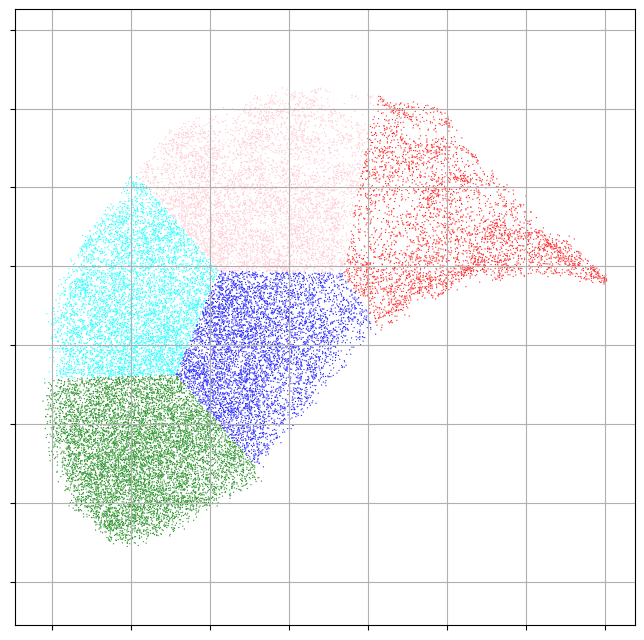

In [11]:
# Cluster probability distributions

cluster_colors = {
    0: "blue",
    1: "pink",
    2: "cyan",
    3: "green",
    4: "red",
}

cluster_probs = {cluster_id: selected_probs[kmeans_label.labels_ == cluster_id]
    for cluster_id in range(5)}

for cluster_id in range(5):
    values = cluster_probs[cluster_id]
    print(f"Cluster {cluster_id}: "
        f"color={cluster_colors[cluster_id]}, "
        f"n={len(values)}, "
        f"mean={np.mean(values):.6f}")



fig, ax = plt.subplots(figsize=(8, 8))

sns.scatterplot(
    x=each_pt_embedding[:, 0],
    y=each_pt_embedding[:, 1],
    c=[cluster_colors[x] for x in kmeans_label.labels_],
    s=0.8,
    ax=ax
)

ax.grid(True)
ax.axis("equal")
ax.set_xticklabels([])
ax.set_yticklabels([])

plt.show()

Cluster 1 : mean=0.4125, SEM=0.0020
Cluster 2 : mean=0.4308, SEM=0.0023
Cluster 3 : mean=0.4440, SEM=0.0022
Cluster 4 : mean=0.4778, SEM=0.0025
Cluster 5 : mean=0.5272, SEM=0.0033


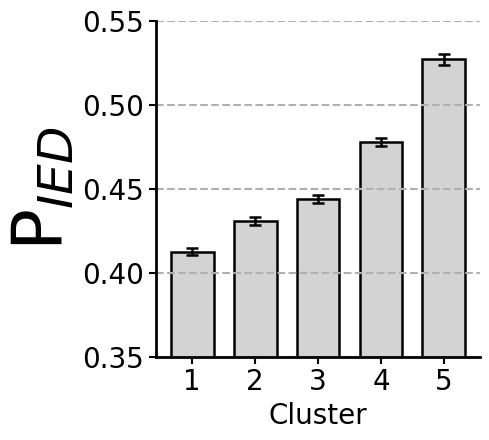

Cluster means: [np.float64(0.4125029088725461), np.float64(0.4307819175029224), np.float64(0.4440204516814135), np.float64(0.47784844003699467), np.float64(0.5271849572426869)]
Cluster SEMs: [np.float64(0.0019632468995914036), np.float64(0.0022559772608236155), np.float64(0.0022181627063323473), np.float64(0.0025498055729581046), np.float64(0.0033159990270340573)]


In [12]:
# Cluster mean ± SEM
# Preserve the original display order used in the notebook.
cluster_display_order = [3, 2, 0, 1, 4]

cluster_data = [
    np.asarray(cluster_probs[cluster_id])
    for cluster_id in cluster_display_order
]

cluster_means = [
    np.nanmean(data)
    for data in cluster_data
]

cluster_sems = [
    np.nanstd(data, ddof=1) / np.sqrt(np.sum(~np.isnan(data)))
    for data in cluster_data
]

for bar_idx, (cluster_id, mean, sem) in enumerate(
    zip(cluster_display_order, cluster_means, cluster_sems),
    start=1
):
    print(
        f"Cluster {bar_idx} : "
        f"mean={mean:.4f}, "
        f"SEM={sem:.4f}"
    )

labels = ["1", "2", "3", "4", "5"]
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(5, 4.5))

ax.bar(x,
    cluster_means,
    width=0.68,
    color="lightgray",
    edgecolor="black",
    linewidth=1.8,
    yerr=cluster_sems,
    capsize=4,
    error_kw={
        "ecolor": "black",
        "elinewidth": 1.8,
        "capthick": 1.8
    }
)

ax.set_xlabel("Cluster", fontsize=20)
ax.set_ylabel("P$_{IED}$", fontsize=50)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=20)
ax.tick_params(axis="y", labelsize=20)

ax.set_ylim(0.35, 0.55)

ax.grid(
    True,
    axis="y",
    linestyle="--",
    linewidth=1.5,
    alpha=1
)
# ax.grid(False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(2)
ax.spines["bottom"].set_linewidth(2)

ax.tick_params(
    axis="both",
    width=1.5,
    length=5
)

plt.tight_layout()
plt.show()

print("Cluster means:", cluster_means)
print("Cluster SEMs:", cluster_sems)

## 20×20 probability heatmap with KMeans boundaries

This fixes the original bug where the loop used `prob_values` as both the probability and the patient identifier.  
Here `selected_patients` is the true patient label aligned to each of the 30,162 points.
This corrected version assigns the grid extrema to the nearest edge bin, includes **all 30,162 candidates**, and saves `Figure6_B_grid.npz` to compare directly with `Figure6_D_corrected_grid.npz`. Both notebooks must run against the same feature data and environment for identical UMAP coordinates.

**Display-only sensitivity view:** bins with fewer than five candidates are masked white in Figure 6B. The underlying probabilities, candidate assignment, and exported `Figure6_B_grid.npz` remain unchanged, so comparisons against C/D still use all 30,162 candidates. Apply the same display threshold to C/D if comparing the filtered heatmaps.


In [13]:
# 20 x 20 grid over the selected 30,162-point embedding
min_vals = np.min(each_pt_embedding, axis=0)
max_vals = np.max(each_pt_embedding, axis=0)

grid_size = (20, 20)

x_bins = np.linspace(min_vals[0], max_vals[0], grid_size[0] + 1)
y_bins = np.linspace(min_vals[1], max_vals[1], grid_size[1] + 1)

grid_prob_sum = {}
grid_count = {}
grid_patient_count = {}

assert len(each_pt_embedding) == len(prob_values) == len(selected_patients)

for (x_coord, y_coord), prob, patient in zip(
    each_pt_embedding,
    prob_values,
    selected_patients
):
    # Same indexing convention as Figure6_D_corrected:
    # interior bin-edge points go to the bin on their left; clip the extrema
    # so that every one of the 30,162 candidates appears in the heatmap.
    x_idx = int(np.clip(np.searchsorted(x_bins, x_coord, side="left") - 1,
                        0, grid_size[0] - 1))
    y_idx = int(np.clip(np.searchsorted(y_bins, y_coord, side="left") - 1,
                        0, grid_size[1] - 1))

    key = (x_idx, y_idx)

    if key not in grid_prob_sum:
        grid_prob_sum[key] = 0.0
        grid_count[key] = 0
        grid_patient_count[key] = set()

    grid_prob_sum[key] += prob
    grid_count[key] += 1
    grid_patient_count[key].add(patient)

grid_probability_value = np.full(grid_size, np.nan, dtype=float)

for i in range(grid_size[0]):
    for j in range(grid_size[1]):
        key = (i, j)

        if key not in grid_prob_sum:
            continue

        # Do not hide occupied bins even when only one patient is present.
        grid_probability_value[i, j] = (
            grid_prob_sum[key] / grid_count[key]
        )

masked_data = np.ma.masked_invalid(grid_probability_value.T)

print(
    "Valid heatmap cells:",
    np.sum(~np.isnan(grid_probability_value))
)

print(
    "Heatmap value range:",
    np.nanmin(grid_probability_value),
    np.nanmax(grid_probability_value)
)
# Reference for the optional cross-check in Figure6_D_corrected.ipynb.
# grid_count is a dictionary keyed by (x_bin, y_bin); export it as 20x20.
grid_count_B = np.zeros(grid_size, dtype=np.int64)
for (i, j), count in grid_count.items():
    assert 0 <= i < grid_size[0] and 0 <= j < grid_size[1]
    grid_count_B[i, j] = count
assert int(grid_count_B.sum()) == EXPECTED_SELECTED_N
assert np.array_equal(np.isnan(grid_probability_value), grid_count_B == 0)
print("Candidates assigned to bins:", int(grid_count_B.sum()))
print("Occupied bins:", int(np.count_nonzero(grid_count_B)))

# Display-only filter: hide bins with fewer than 5 candidates.
# Keep grid_probability_value, grid_count_B and Figure6_B_grid.npz UNFILTERED
# so B/C/D still share the exact same 30,162-candidate geometry and counts.
MIN_CANDIDATES_PER_BIN = 5
low_count_bins = (grid_count_B > 0) & (grid_count_B <= MIN_CANDIDATES_PER_BIN)
masked_data = np.ma.masked_where(
    grid_count_B.T < MIN_CANDIDATES_PER_BIN,
    np.ma.masked_invalid(grid_probability_value.T)
)
print(f"Minimum candidates per displayed bin: {MIN_CANDIDATES_PER_BIN}")
print("Occupied bins hidden:", int(low_count_bins.sum()))
print("Candidates in hidden bins:", int(grid_count_B[low_count_bins].sum()))
print("Occupied bins displayed:", int((grid_count_B >= MIN_CANDIDATES_PER_BIN).sum()))

np.savez_compressed(
    "Figure6_B_grid.npz",
    grid_count=grid_count_B,
    grid_mean=grid_probability_value,
    x_bins=x_bins,
    y_bins=y_bins,
    selected_global_idx=selected_global_idx,
    each_pt_embedding=each_pt_embedding,
)
print("Saved: Figure6_B_grid.npz")

# Compare if D has already been rerun in the same working directory.
d_reference = "Figure6_D_corrected_grid.npz"
if os.path.isfile(d_reference):
    with np.load(d_reference) as ref:
        assert np.array_equal(ref["selected_global_idx"], selected_global_idx), "B/D selected candidates differ"
        assert np.array_equal(ref["each_pt_embedding"], each_pt_embedding), "B/D embeddings differ: reuse exactly the same embedding"
        assert np.array_equal(ref["x_bins"], x_bins), "B/D x-bin boundaries differ"
        assert np.array_equal(ref["y_bins"], y_bins), "B/D y-bin boundaries differ"
        assert np.array_equal(ref["grid_count"], grid_count_B), "B/D candidate counts per bin differ"
    print("B/D geometry check passed: same candidates, UMAP, bins, and counts.")
else:
    print("D comparison skipped until Figure6_D_corrected_grid.npz exists.")


Valid heatmap cells: 245
Heatmap value range: 0.19719119966 0.7267792622333333
Candidates assigned to bins: 30162
Occupied bins: 245
Minimum candidates per displayed bin: 5
Occupied bins hidden: 13
Candidates in hidden bins: 38
Occupied bins displayed: 236
Saved: Figure6_B_grid.npz
B/D geometry check passed: same candidates, UMAP, bins, and counts.


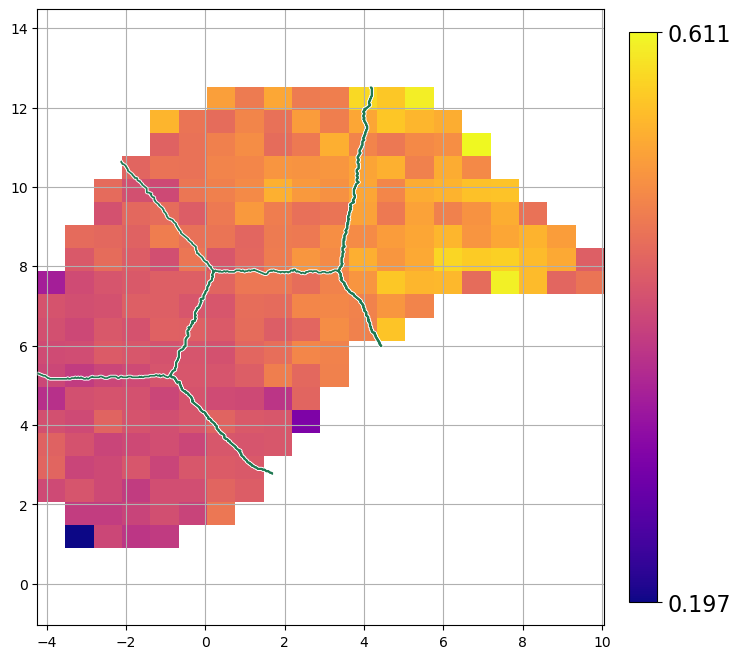

In [22]:
# Heatmap + KNN-reconstructed KMeans boundaries
cmap = plt.colormaps["plasma"].copy()
cmap.set_bad(color="white")

fig, ax = plt.subplots(figsize=(8, 8))

ax.grid(True)
ax.axis("equal")
ax.set_facecolor("white")

c2 = ax.imshow(
    masked_data,
    origin="lower",
    cmap=cmap,
    extent=[
        min_vals[0],
        max_vals[0],
        min_vals[1],
        max_vals[1]
    ]
)

cluster_embedding = each_pt_embedding
cluster_labels = np.asarray(kmeans_label.labels_)

xx, yy = np.meshgrid(
    np.linspace(min_vals[0], max_vals[0], 600),
    np.linspace(min_vals[1], max_vals[1], 600)
)

grid_points = np.c_[xx.ravel(), yy.ravel()]

knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(cluster_embedding, cluster_labels)

Z = knn.predict(grid_points).reshape(xx.shape)

tree = cKDTree(cluster_embedding)
dist, _ = tree.query(grid_points, k=1)
dist = dist.reshape(xx.shape)

dist_thresh = 0.4
Z_masked = np.ma.masked_where(dist > dist_thresh, Z)

# White underlay
ax.contour(
    xx,
    yy,
    Z_masked,
    levels=[0.5, 1.5, 2.5, 3.5],
    colors="white",
    linewidths=2.6,
    alpha=0.95,
    zorder=10
)

# Original green boundary
ax.contour(
    xx,
    yy,
    Z_masked,
    levels=[0.5, 1.5, 2.5, 3.5],
    colors="#1f7952",
    linewidths=1.2,
    alpha=1.0,
    zorder=11
)

vmin = np.nanmin(masked_data)
vmax = np.nanmax(masked_data)

cbar = plt.colorbar(
    c2,
    ax=ax,
    orientation="vertical",
    fraction=0.046,
    pad=0.04
)

cbar.set_ticks([vmin, vmax])
cbar.set_ticklabels([
    f"{vmin:.3f}",
    f"{vmax:.3f}"
])

cbar.ax.tick_params(labelsize=16)

plt.show()

In [23]:
# Final alignment diagnostics
print("GLOBAL N:", len(embedding))
print("SELECTED N:", len(selected_global_idx))
print("GLOBAL INDEX LIST N:", len(global_idx_list))
print("UNIQUE GLOBAL INDEX N:", len(np.unique(global_idx_list)))

print(
    "Excluded counts:",
    {
        patient: int(np.sum(all_specs_label == patient))
        for patient in EXCLUDED_PATIENTS
    }
)

print(
    "Expected selected calculation:",
    EXPECTED_GLOBAL_N
    - sum(int(np.sum(all_specs_label == patient)) for patient in EXCLUDED_PATIENTS)
)

assert len(embedding) == EXPECTED_GLOBAL_N
assert len(selected_global_idx) == EXPECTED_SELECTED_N
assert len(global_idx_list) == EXPECTED_SELECTED_N
assert len(np.unique(global_idx_list)) == EXPECTED_SELECTED_N

assert np.array_equal(
    np.sort(global_idx_list),
    np.sort(selected_global_idx)
)

print("\nAll global-index alignment checks passed.")

GLOBAL N: 31847
SELECTED N: 30162
GLOBAL INDEX LIST N: 30162
UNIQUE GLOBAL INDEX N: 30162
Excluded counts: {'EC130_200': 1465, 'EC183_200': 220}
Expected selected calculation: 30162

All global-index alignment checks passed.


In [24]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

vmin = np.nanmin(masked_data)
vmax = np.nanmax(masked_data)

norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(norm=norm, cmap="plasma")

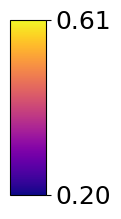

In [25]:
fig = plt.figure(figsize=(1.2, 5))

cax = fig.add_axes([0.45, 0.4, 0.3, 0.35])

cbar = fig.colorbar(
    sm,
    cax=cax,
    orientation="vertical"
)

cbar.set_ticks([vmin, vmax])
cbar.set_ticklabels([
    f"{vmin:.2f}",
    f"{vmax:.2f}"
])

cbar.ax.tick_params(labelsize=18)

plt.show()

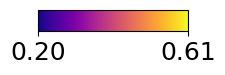

In [26]:
fig = plt.figure(figsize=(5, 1.2))

cax = fig.add_axes([0.4, 0.45, 0.3, 0.18])

cbar = fig.colorbar(
    sm,
    cax=cax,
    orientation="horizontal"
)

cbar.set_ticks([vmin, vmax])
cbar.set_ticklabels([
    f"{vmin:.2f}",
    f"{vmax:.2f}"
])

cbar.ax.tick_params(labelsize=18)

plt.show()

In [27]:
import numpy as np
import matplotlib.pyplot as plt

def plot_probability_scatter(
    embedding,
    probabilities,
    colorbar_label,
    output_stem,
    point_size=4,
    cmap="plasma",
    vmin=None,
    vmax=None
):
    embedding = np.asarray(embedding)
    probabilities = np.asarray(probabilities)

    assert embedding.shape[0] == len(probabilities), \
        f"embedding rows ({embedding.shape[0]}) != probabilities ({len(probabilities)})"

    fig, ax = plt.subplots(figsize=(8, 8))

    sc = ax.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=probabilities,
        cmap=cmap,
        s=point_size,
        linewidths=0,
        # alpha=0.9,
        vmin=vmin,
        vmax=vmax
    )

    ax.grid(True)
    ax.axis("equal")

    cbar = fig.colorbar(
        sc,
        ax=ax,
        orientation="vertical",
        fraction=0.046,
        pad=0.04
    )
    cbar.set_label(colorbar_label, fontsize=16)
    cbar.ax.tick_params(labelsize=12)

    plt.tight_layout()

    fig.savefig(output_stem + ".png", dpi=300, bbox_inches="tight")
    fig.savefig(output_stem + ".pdf", bbox_inches="tight")

    plt.show()

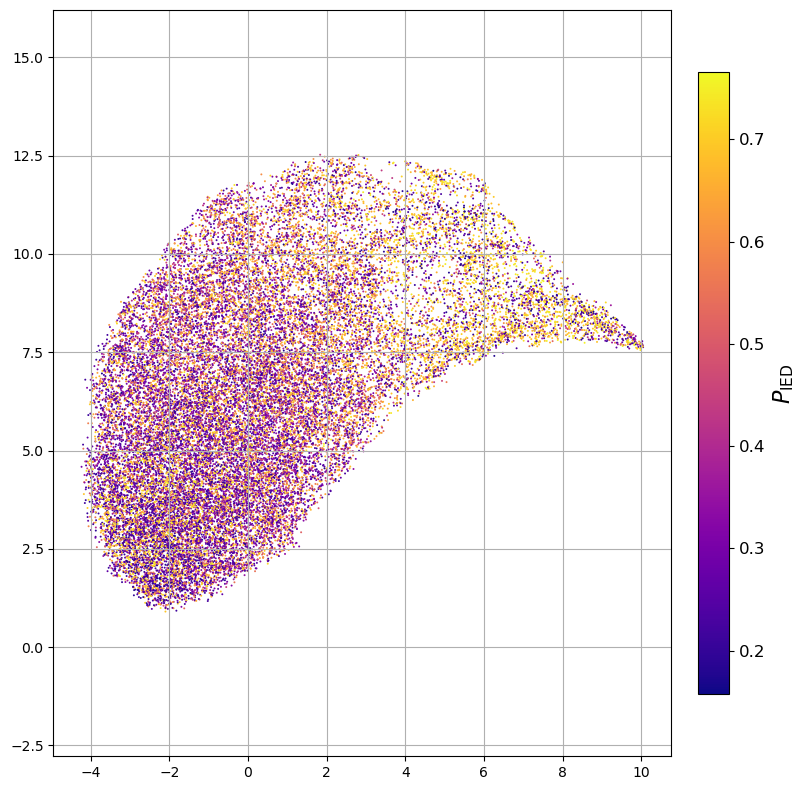

In [28]:
plot_probability_scatter(
    embedding=each_pt_embedding,
    probabilities=selected_probs,
    colorbar_label=r"$P_{\mathrm{IED}}$",
    output_stem="Figure6_B_corrected_scatter",
    point_size=2
)

In [21]:
# # ============================================================
# # Figure 6B: Print candidate count and average probability
# # for all 20 x 20 bins
# # ============================================================

# import numpy as np
# import pandas as pd

# bin_results = []

# for i in range(20):
#     for j in range(20):

#         key = (i, j)

#         n_candidates = grid_count.get(key, 0)

#         avg_prob = grid_probability_value[i, j]

#         bin_results.append({
#             "Bin_X": i,
#             "Bin_Y": j,
#             "N_candidates": n_candidates,
#             "Avg_P_IED": avg_prob,
#             "X_min": x_bins[i],
#             "X_max": x_bins[i + 1],
#             "Y_min": y_bins[j],
#             "Y_max": y_bins[j + 1],
#         })

# df_bins = pd.DataFrame(bin_results)

# print(df_bins.to_string(index=False))